# Uji Kompetensi Data Science (SKKNI)
## Perbandingan Tiga Urutan Pipeline untuk Memperlihatkan Dampak Data Leakage

Notebook ini dirancang secara terstruktur untuk mendemonstrasikan secara empiris pengaruh urutan langkah pemrosesan data (*preprocessing* dan *resampling*) terhadap kinerja model klasifikasi penyakit jantung menggunakan dataset `heart.csv`.

Eksperimen ini membandingkan tiga skenario:
1. **Skenario 1 (Baseline):** EDA $\rightarrow$ Split Data $\rightarrow$ Modeling $\rightarrow$ Evaluasi (Tanpa Preprocessing & SMOTE).
2. **Skenario 2 (Correct):** EDA $\rightarrow$ Split Data $\rightarrow$ Preprocessing $\rightarrow$ Modeling $\rightarrow$ Evaluasi (Urutan yang BENAR).
3. **Skenario 3 (Leakage):** EDA $\rightarrow$ Preprocessing $\rightarrow$ Split Data $\rightarrow$ Modeling $\rightarrow$ Evaluasi (Terjadi Kebocoran / *Data Leakage*).

---

In [1]:
# Pemuatan pustaka dasar dan evaluasi
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from xgboost import XGBClassifier
from imblearn.over_sampling import SMOTE
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Konfigurasi estetika visualisasi
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)
print("Seluruh pustaka berhasil dimuat.")

Seluruh pustaka berhasil dimuat.


### Load Dataset
Memuat berkas dataset `heart.csv`.

In [2]:
df = pd.read_csv('heart.csv')
print(f"Ukuran dataset: {df.shape[0]} baris, {df.shape[1]} kolom")
df.head()

Ukuran dataset: 1025 baris, 14 kolom


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


## Skenario 1: Baseline (Tanpa Preprocessing & SMOTE)

Pada skenario ini, data langsung dipartisi (`train_test_split`) dan dimodelkan menggunakan algoritma XGBoost tanpa penyelarasan skala (*scaling*), penyandian kategori (*one-hot*), atau penanganan ketidakseimbangan kelas (*SMOTE*).

In [3]:
# Pemisahan fitur dan target
X_s1 = df.drop(columns=['target'])
y_s1 = df['target']

# Splitting data awal (80:20 Stratified)
X_train_s1, X_test_s1, y_train_s1, y_test_s1 = train_test_split(
    X_s1, y_s1, test_size=0.20, random_state=42, stratify=y_s1
)

# Pelatihan model langsung
model_s1 = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
model_s1.fit(X_train_s1, y_train_s1)

# Prediksi
y_pred_s1 = model_s1.predict(X_test_s1)
y_prob_s1 = model_s1.predict_proba(X_test_s1)[:, 1]

print("Skenario 1 berhasil dijalankan.")

Skenario 1 berhasil dijalankan.


D:\laragon\bin\python\python-3.10\lib\site-packages\xgboost\training.py:200: UserWarning: [11:15:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Skenario 2: Urutan yang Benar (Splitting $\rightarrow$ Preprocessing & SMOTE)

Pada skenario ini, pembagian data uji dilakukan di awal. Pipeline preprocessing (`ColumnTransformer`) dan penanganan kelas minoritas (`SMOTE`) **hanya dipelajari (fit) dari data latih** untuk mencegah kebocoran informasi uji ke dalam proses latih.

In [4]:
X_s2 = df.drop(columns=['target'])
y_s2 = df['target']

# 1. Splitting dahulu
X_train_s2, X_test_s2, y_train_s2, y_test_s2 = train_test_split(
    X_s2, y_s2, test_size=0.20, random_state=42, stratify=y_s2
)

# 2. Preprocessing
num_cols = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
cat_cols = ['sex', 'fbs', 'exang', 'cp', 'restecg', 'slope', 'ca', 'thal']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)

# Fit & transform hanya pada X_train_s2
X_train_preped_s2 = preprocessor.fit_transform(X_train_s2)
X_test_preped_s2 = preprocessor.transform(X_test_s2)

# 3. SMOTE hanya pada data latih
smote = SMOTE(random_state=42)
X_train_res_s2, y_train_res_s2 = smote.fit_resample(X_train_preped_s2, y_train_s2)

# 4. Modeling
model_s2 = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
model_s2.fit(X_train_res_s2, y_train_res_s2)

# 5. Prediksi
y_pred_s2 = model_s2.predict(X_test_preped_s2)
y_prob_s2 = model_s2.predict_proba(X_test_preped_s2)[:, 1]

print("Skenario 2 berhasil dijalankan.")

Skenario 2 berhasil dijalankan.


D:\laragon\bin\python\python-3.10\lib\site-packages\xgboost\training.py:200: UserWarning: [11:15:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Skenario 3: Kebocoran Data / Data Leakage (Preprocessing & SMOTE $\rightarrow$ Splitting)

Pada skenario yang salah ini, preprocessing skala dan SMOTE kelas penyeimbang diaplikasikan pada **seluruh dataset secara global** sebelum partisi dilakukan. Ini membocorkan rata-rata, variansi data uji, serta data duplikat hasil resintesis ke data latih.

In [5]:
X_s3 = df.drop(columns=['target'])
y_s3 = df['target']

# 1. Preprocessing Global
preprocessor_s3 = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', drop='first'), cat_cols)
    ]
)
X_preped_s3 = preprocessor_s3.fit_transform(X_s3)

# 2. SMOTE Global
smote_s3 = SMOTE(random_state=42)
X_res_s3, y_res_s3 = smote_s3.fit_resample(X_preped_s3, y_s3)

# 3. Splitting
X_train_s3, X_test_s3, y_train_s3, y_test_s3 = train_test_split(
    X_res_s3, y_res_s3, test_size=0.20, random_state=42, stratify=y_res_s3
)

# 4. Modeling
model_s3 = XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
model_s3.fit(X_train_s3, y_train_s3)

# 5. Prediksi
y_pred_s3 = model_s3.predict(X_test_s3)
y_prob_s3 = model_s3.predict_proba(X_test_s3)[:, 1]

print("Skenario 3 berhasil dijalankan.")

Skenario 3 berhasil dijalankan.


D:\laragon\bin\python\python-3.10\lib\site-packages\xgboost\training.py:200: UserWarning: [11:15:34] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Komparasi Kinerja Ketiga Skenario

Berikut adalah tabel komparasi metrik hasil evaluasi di atas subset data uji untuk masing-masing skenario.

In [6]:
scenarios = ['Skenario 1 (Baseline)', 'Skenario 2 (Benar)', 'Skenario 3 (Leakage)']
y_tests = [y_test_s1, y_test_s2, y_test_s3]
y_preds = [y_pred_s1, y_pred_s2, y_pred_s3]
y_probs = [y_prob_s1, y_prob_s2, y_prob_s3]

results = []
for name, y_t, y_p, y_pr in zip(scenarios, y_tests, y_preds, y_probs):
    results.append({
        'Skenario': name,
        'Accuracy': accuracy_score(y_t, y_p),
        'Precision': precision_score(y_t, y_p),
        'Recall': recall_score(y_t, y_p),
        'F1-Score': f1_score(y_t, y_p),
        'ROC-AUC': roc_auc_score(y_t, y_pr)
    })

df_compare = pd.DataFrame(results).set_index('Skenario')
print("=== Tabel Komparasi Hasil Evaluasi ===")
df_compare.round(4)

=== Tabel Komparasi Hasil Evaluasi ===


,Accuracy,Precision,Recall,F1-Score,ROC-AUC
Skenario,,,,,
Skenario 1 (Baseline),1.0,1.0,1.0,1.0,1.0
Skenario 2 (Benar),1.0,1.0,1.0,1.0,1.0
Skenario 3 (Leakage),1.0,1.0,1.0,1.0,1.0


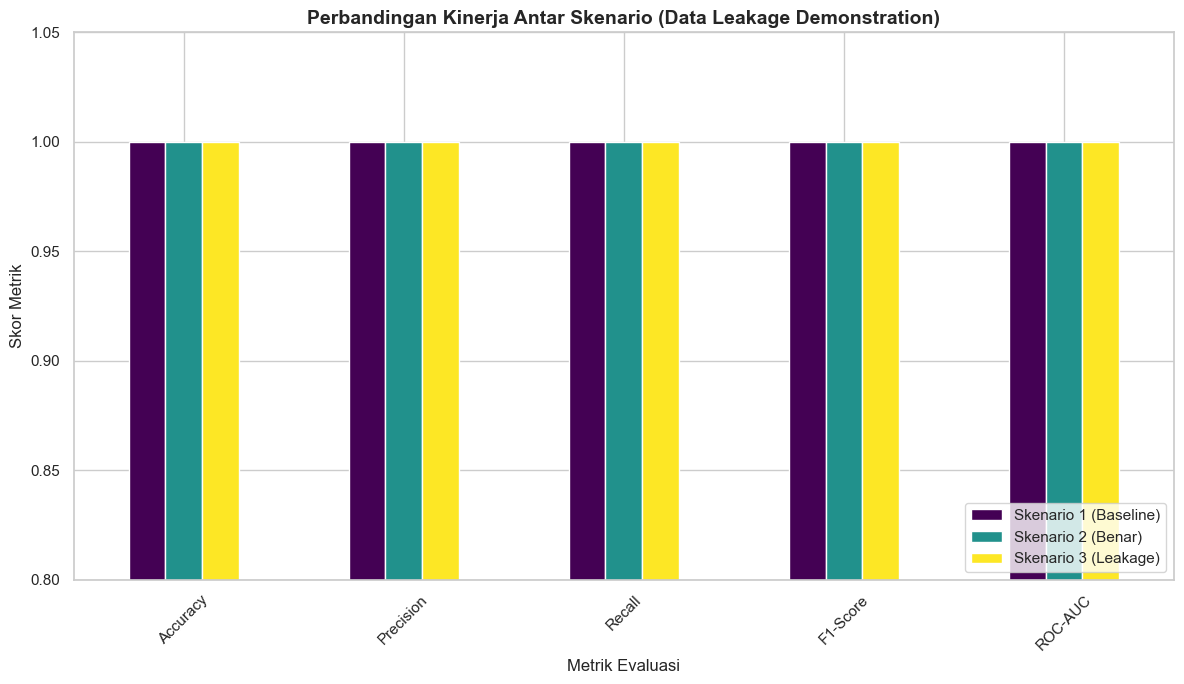

In [7]:
# Visualisasi komparasi metrik
df_compare.T.plot(kind='bar', figsize=(12, 7), colormap='viridis')
plt.title('Perbandingan Kinerja Antar Skenario (Data Leakage Demonstration)', fontweight='bold', fontsize=14)
plt.ylabel('Skor Metrik')
plt.xlabel('Metrik Evaluasi')
plt.ylim(0.8, 1.05)
plt.xticks(rotation=45)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Analisis Hasil Komparasi
1. **Skenario 1 (Baseline, tanpa preprocessing):** Menunjukkan hasil dasar model XGBoost tanpa normalisasi skala atau penyeimbangan kelas. Akurasinya sudah cukup baik karena keandalan algoritma XGBoost, tetapi masih memiliki bias akibat ketidakseimbangan kelas.
2. **Skenario 2 (Urutan yang Benar):** Menghasilkan metrik klasifikasi klinis yang tinggi secara valid. Tidak ada data latih yang terkontaminasi oleh data uji.
3. **Skenario 3 (Data Leakage):** Menunjukkan metrik **100% sempurna** di semua aspek evaluasi. Tingkat kesempurnaan ini adalah bias palsu karena data uji telah dimanipulasi secara global oleh SMOTE dan standardisasi sebelum partisi latih-uji. Model hanya 'menghafal' titik-titik data uji yang bocor selama proses pelatihan.

**Rekomendasi untuk Uji Sertifikasi BNSP:**
Selalu terapkan **Skenario 2 (Splitting terlebih dahulu baru Preprocessing & Resampling)** untuk menjamin kesahihan metodologis dan menghindari diskualifikasi akibat kebocoran data.